In [1]:
import numpy as np
import pyvisa as visa
from instrumentlib import KeysightXSeries, RhodeandSchwarz_SGS100A
import time
import matplotlib.pyplot as plt

In [2]:
GHz = 1e9
MHz = 1e6
kHz = 1e3

In [9]:
address_sa = "TCPIP0::192.168.0.117::inst0::INSTR"
address_rf = "TCPIP0::192.168.0.120::inst0::INSTR"

In [10]:
calib = KeysightXSeries(address_sa)
rf_input = RhodeandSchwarz_SGS100A(address_rf)

In [14]:
freq = 5.1 # GHz
power = -20 #dBm

In [15]:
rf_input.set_freq_GHz(freq)
rf_input.set_power_dB(power)

In [12]:
center_freq = freq * GHz
span = 100

calib.set_bandwidth(5)
calib.set_sweep_points(501)

calib.set_center_freq(center_freq)
calib.set_span(span)
calib.active_marker(1)
calib.set_marker_freq(1, center_freq)

In [13]:
rf_input.output_toggle()

In [47]:
pmin, pmax, dp = -20, 14, 1
power_list = np.arange(pmin, pmax, dp)

output_list = []
for power in power_list:
    
    rf_input.set_power_dB(power)
    time.sleep(2)
    p = calib.query_marker(1)
    output_list.append(p)

In [48]:
 output_list_zx60_83MP_Splus_1 = output_list

In [51]:
output_list_zx60_83MP_Splus_1[0] =  output_list_zx60_83MP_Splus[0]
output_list_zx60_83MP_Splus_1[1] =  output_list_zx60_83MP_Splus[1]
output_list_zx60_83MP_Splus_1[2] =  output_list_zx60_83MP_Splus[2]

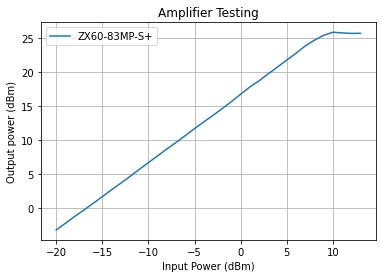

In [52]:
plt.plot(power_list, output_list_zx60_83MP_Splus_1, label = "ZX60-83MP-S+")
plt.xlabel("Input Power (dBm)")
plt.ylabel("Output power (dBm)")
plt.title("Amplifier Testing")
plt.legend()
plt.grid()

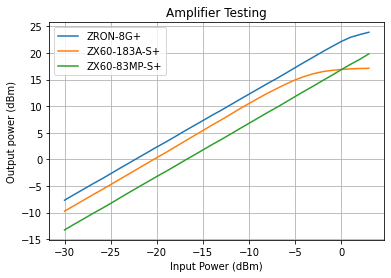

In [43]:
plt.plot(power_list, output_list_zron, label = "ZRON-8G+")
plt.plot(power_list, output_list_zx60_183A_S, label = "ZX60-183A-S+")
plt.plot(power_list, output_list_zx60_83MP_Splus, label = "ZX60-83MP-S+")
plt.xlabel("Input Power (dBm)")
plt.ylabel("Output power (dBm)")
plt.title("Amplifier Testing")
plt.legend()
plt.grid()

In [17]:
rf_input.query("SOUR:FREQ:CW?")
rf_input.close_connection()

5100000000
